# SimGuard — Stage 1: Isolation Forest

Unsupervised SIM anomaly detection pipeline.

**Cell map**

| # | Cell | Purpose |
|---|------|---------|
| 1 | Imports & installs | pip, all library imports, warnings |
| 2 | Paths & seed | SEED, DATA\_DIR, ARTIFACT\_DIR |
| 3 | MLflow setup | tracking URI, experiment |
| 4 | Load data | read 6 parquet splits, print shapes |
| 5 | Feature matrix | drop sim\_id/date, print feature list |
| 6 | Feature cross-check | validate against feature\_columns.json |
| 7 | Pre-fit sanity | assert no label leakage in X\_train |
| 8 | Fit + log params | IsolationForest on X\_train, MLflow params |
| 9 | Score | decision\_function + predict on val & test |
| 10 | Join | attach scores to labels via sim\_id+date |
| 11 | Val metrics | overall + per-category, log to MLflow |
| 12 | Test metrics | final one-time evaluation, log to MLflow |
| 13 | PR curve | precision-recall across all thresholds |
| 14 | Permutation importance | corrected sign scorer |
| 15 | Save + end run | log\_model, joblib, summary, end\_run() |



In [1]:
!pip install -q scikit-learn shap mlflow pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [2]:
# Cell 1: Imports & Installs

import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib

import mlflow
import mlflow.sklearn

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore', category=UserWarning)

print(' Imports complete.')

 Imports complete.


## Cell 2 — Reproducibility & Paths

Set `SEED`, directory paths, and create `ARTIFACT_DIR` if absent.
**Colab users:** if your upload placed `ml-service/` at a non-default location,
adjust `DATA_DIR` and `ARTIFACT_DIR` here.

In [3]:
# Cell 2: Reproducibility & Paths

SEED = 42
np.random.seed(SEED)

# Updated for Google Colab default directory structure
DATA_DIR     = '/content'
ARTIFACT_DIR = '/content/artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f'SEED         : {SEED}')
print(f'DATA_DIR     : {os.path.abspath(DATA_DIR)}')
print(f'ARTIFACT_DIR : {os.path.abspath(ARTIFACT_DIR)}')
print('Paths ready.')

SEED         : 42
DATA_DIR     : /content
ARTIFACT_DIR : /content/artifacts
Paths ready.


## Cell 3 — MLflow Tracking Setup

Configures the MLflow tracking URI and experiment.

**MLflow ≥ 3.x note:** the filesystem store (`file:./mlruns`) is deprecated;
we use SQLite (`sqlite:///mlruns.db`) instead.
`MLFLOW_ALLOW_FILE_STORE=true` is set as a fallback for older installs.

In [4]:
# Cell 3: MLflow Tracking Setup

# Fallback for MLflow < 3.x installs that still use the filesystem store
os.environ.setdefault('MLFLOW_ALLOW_FILE_STORE', 'true')

# SQLite backend
MLFLOW_DB = 'sqlite:///mlruns.db'
mlflow.set_tracking_uri(MLFLOW_DB)
mlflow.set_experiment('simguard-stage1-isolation-forest')

print(f'MLflow tracking URI : {mlflow.get_tracking_uri()}')
print(f'MLflow experiment   : simguard-stage1-isolation-forest')
print('MLflow configured.')

2026/10/01 00:09:04 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/01 00:09:04 INFO mlflow.store.db.utils: Updating database tables
2026/10/01 00:09:07 INFO mlflow.tracking.fluent: Experiment with name 'simguard-stage1-isolation-forest' does not exist. Creating a new experiment.


MLflow tracking URI : sqlite:///mlruns.db
MLflow experiment   : simguard-stage1-isolation-forest
MLflow configured.


## Cell 4 — Load Parquet Splits

Reads the six split files produced by `feature_engineering.ipynb`.
X and y are loaded into separate DataFrames and **never merged** before evaluation.

In [5]:
# Cell 4: Load Parquet Splits

X_train_raw = pd.read_parquet(os.path.join(DATA_DIR, 'X_train.parquet'))
X_val_raw   = pd.read_parquet(os.path.join(DATA_DIR, 'X_val.parquet'))
X_test_raw  = pd.read_parquet(os.path.join(DATA_DIR, 'X_test.parquet'))
y_train     = pd.read_parquet(os.path.join(DATA_DIR, 'y_train.parquet'))
y_val       = pd.read_parquet(os.path.join(DATA_DIR, 'y_val.parquet'))
y_test      = pd.read_parquet(os.path.join(DATA_DIR, 'y_test.parquet'))

print('Split shapes:')
print(f'  X_train_raw : {X_train_raw.shape}   y_train : {y_train.shape}')
print(f'  X_val_raw   : {X_val_raw.shape}     y_val   : {y_val.shape}')
print(f'  X_test_raw  : {X_test_raw.shape}    y_test  : {y_test.shape}')
print('Data loaded. X and y are separate DataFrames.')

Split shapes:
  X_train_raw : (63000, 44)   y_train : (63000, 4)
  X_val_raw   : (13500, 44)     y_val   : (13500, 4)
  X_test_raw  : (13500, 44)    y_test  : (13500, 4)
Data loaded. X and y are separate DataFrames.


## Cell 5 — Feature Matrix Preparation

Detects `sim_id` and `date` columns in `X_*`, retains them as join keys for later,
and drops them from the feature matrices passed to the model.
Prints the dropped columns and the final feature list.

In [6]:
# Cell 5: Feature Matrix Preparation

KEY_COLS         = ['sim_id', 'date']
present_key_cols = [c for c in KEY_COLS if c in X_train_raw.columns]
absent_key_cols  = [c for c in KEY_COLS if c not in X_train_raw.columns]

# Retain join keys from each split (used only at the evaluation join step)
X_train_keys = X_train_raw[present_key_cols].copy() if present_key_cols else None
X_val_keys   = X_val_raw[present_key_cols].copy()   if present_key_cols else None
X_test_keys  = X_test_raw[present_key_cols].copy()  if present_key_cols else None

# Pure feature matrices — no identifier columns
X_train = X_train_raw.drop(columns=present_key_cols)
X_val   = X_val_raw.drop(columns=present_key_cols)
X_test  = X_test_raw.drop(columns=present_key_cols)

feature_cols = list(X_train.columns)

print(f'Dropped from feature matrix : {present_key_cols}')
if absent_key_cols:
    print(f'Not present (no action)     : {absent_key_cols}')
print(f'Feature count               : {len(feature_cols)}')
print(f'Feature list                : {feature_cols}')
print('Feature matrices prepared.')

Dropped from feature matrix : ['sim_id', 'date']
Feature count               : 42
Feature list                : ['total_download_mb', 'total_upload_mb', 'data_session_count', 'data_duration_s', 'hotspot_sessions', 'public_apn_sessions', 'unique_towers', 'geo_flag_count', 'peak_mb', 'offpeak_mb', 'total_mb', 'roaming_sessions', 'billed_mb', 'voice_minutes_used', 'sms_count', 'voice_minutes_remaining', 'sms_remaining', 'billing_gap_mb', 'billing_ratio', 'offpeak_ratio', 'public_apn_ratio', 'upload_ratio', 'bytes_per_session', 'mean_session_duration_s', 'hotspot_session_ratio', 'has_geo_anomaly', 'vol_rolling_7d_mean', 'vol_rolling_7d_std', 'vol_zscore_7d', 'hotspot_sum_7d', 'geo_sum_7d', 'vol_rolling_14d_mean', 'vol_rolling_14d_std', 'vol_zscore_14d', 'hotspot_sum_14d', 'geo_sum_14d', 'trend_slope_14d', 'tier_field', 'tier_manager', 'tier_professional', 'tier_support', 'voice_utilization_ratio']
Feature matrices prepared.


## Cell 6 — Feature Column Cross-Check

Validates that `feature_cols` (from the live parquet) exactly matches the list
saved to `artifacts/feature_columns.json` by `feature_engineering.ipynb`.
Any mismatch here would mean the scaler and model would be applied to wrong features.

In [7]:
# Cell 6: Feature Column Cross-Check

feat_json_path = os.path.join(ARTIFACT_DIR, 'feature_columns.json')

if os.path.exists(feat_json_path):
    with open(feat_json_path) as _f:
        saved_features = json.load(_f)['features']
    extra   = set(feature_cols) - set(saved_features)
    missing = set(saved_features) - set(feature_cols)
    if not extra and not missing:
        print(f'feature_columns.json matches X_train exactly ({len(feature_cols)} features).')
    else:
        print(f'MISMATCH — extra in parquet : {extra}')
        print(f'             missing from parquet: {missing}')
else:
    print('feature_columns.json not found — skipping cross-check.')

feature_columns.json matches X_train exactly (42 features).


## Cell 7 — Pre-Fit Sanity Check

Asserts that no target label columns (`is_anomalous`, `misuse_category`) are
present in `X_train`. This would indicate an accidental X/y merge before fitting,
which would be a training-time label leak.

In [8]:
# Cell 7: Pre-Fit Sanity Check

TARGET_COLS = ['is_anomalous', 'misuse_category']
leakage = [c for c in TARGET_COLS if c in X_train.columns]
assert len(leakage) == 0, f'TARGET LEAK in X_train: {leakage}'

print('X_train contains no target columns — no label leakage.')
print('X and y DataFrames are separate and will only join at the evaluation step.')

X_train contains no target columns — no label leakage.
X and y DataFrames are separate and will only join at the evaluation step.


## Cell 8 — Fit IsolationForest & Log Params

Fits `IsolationForest` on `X_train` features only — **unsupervised**.
`y_train` is never passed to `fit()` or consulted at any point before Cell 11.

Opens the MLflow run with `mlflow.start_run()` (no `with`-block) so the run
stays active across all subsequent cells in the same kernel session.
Call `mlflow.end_run()` in Cell 15 to close it cleanly.

**contamination=`'auto'`**: IsolationForest internally sets the decision threshold
so approximately 10 % of training points are labelled outliers.
We log the *observed* flagged fraction on `X_train` as `contamination` (not the
string `'auto'`), which is the value that actually governs `predict()`.

In [9]:
# Cell 8: Fit IsolationForest & Log Params

# Close any leftover active run (safe to re-run this cell)
if mlflow.active_run() is not None:
    print(f'  Closing stale run: {mlflow.active_run().info.run_id}')
    mlflow.end_run()

active_run = mlflow.start_run(run_name='isoforest-contamination-auto')
RUN_ID = active_run.info.run_id
print(f'MLflow run started  : {RUN_ID}')
print(f'Tracking URI        : {mlflow.get_tracking_uri()}')

#  Fit (unsupervised — y_train is never used)
print('\nFitting IsolationForest on X_train …')
iso = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=SEED,
    n_jobs=-1,
)
iso.fit(X_train)
print('  Fit complete.')

# Actual flagged fraction on train (what 'auto' resolved to)
train_flags          = iso.predict(X_train)
actual_contamination = float((train_flags == -1).mean())
print(f'  contamination arg              : "auto"')
print(f'  Actual flagged fraction (train): {actual_contamination:.4f}')

# Log params
mlflow.log_param('contamination',       actual_contamination)
mlflow.log_param('contamination_arg',   'auto')
mlflow.log_param('n_estimators',        200)
mlflow.log_param('random_state',        SEED)
mlflow.log_param('n_features',          len(feature_cols))
mlflow.log_param('n_train_samples',     len(X_train))
mlflow.log_param('n_val_samples',       len(X_val))
mlflow.log_param('n_test_samples',      len(X_test))
print('\n Params logged to MLflow.')

MLflow run started  : 1defa620066745398a061238d1a99075
Tracking URI        : sqlite:///mlruns.db

Fitting IsolationForest on X_train …
  Fit complete.
  contamination arg              : "auto"
  Actual flagged fraction (train): 0.0499

 Params logged to MLflow.


## Cell 9 — Score Val & Test Sets

`decision_function` returns a continuous anomaly score: **higher = more normal**.
`predict` returns −1 (outlier) or +1 (inlier) based on the `contamination` threshold.

Both val and test are scored here, but the test scores are **not inspected** until
Cell 12 (the single one-time final evaluation).

In [10]:
# Cell 9: Score Val & Test Sets

# Val
val_scores = iso.decision_function(X_val)   # higher → more normal
val_preds  = iso.predict(X_val)              # -1 = anomaly, +1 = inlier

# Test — scored here, inspected once in Cell 12 only
test_scores = iso.decision_function(X_test)
test_preds  = iso.predict(X_test)

print('Flagged-anomaly summary:')
print(f'  Val  : {(val_preds  == -1).sum():,} / {len(val_preds):,}  ({(val_preds  == -1).mean()*100:.2f}%)')
print(f'  Test : {(test_preds == -1).sum():,} / {len(test_preds):,}  ({(test_preds == -1).mean()*100:.2f}%)')
print('\n Scoring complete.')
print('  Test scores are stored but will not be inspected until Cell 12.')

Flagged-anomaly summary:
  Val  : 852 / 13,500  (6.31%)
  Test : 863 / 13,500  (6.39%)

 Scoring complete.
  Test scores are stored but will not be inspected until Cell 12.


## Cell 10 — Join Scores to Labels

Attaches `anomaly_score` and `pred_flag` to `y_val` / `y_test` via an inner join
on `sim_id + date`. Row-count assertions verify no rows were dropped or duplicated.

This is the **first and only** point where X-derived data and y labels are combined.

In [11]:
# Cell 10: Join Scores to Labels

def _join(keys_df, scores_arr, preds_arr, y_df, name):
    df = keys_df.copy()
    df['anomaly_score'] = scores_arr
    df['pred_flag']     = preds_arr
    before = len(df)
    merged = y_df.merge(df, on=['sim_id', 'date'], how='inner')
    after  = len(merged)
    print(f'  [{name}] y={len(y_df):,}  scores={before:,}  merged={after:,}', end='  ')
    assert after == len(y_df), f'{name}: row count changed ({len(y_df):,} → {after:,})'
    return merged

print('Joining scores to labels via sim_id + date:')
val_merged  = _join(X_val_keys,  val_scores,  val_preds,  y_val,  'Val')
test_merged = _join(X_test_keys, test_scores, test_preds, y_test, 'Test')

print(f'\n  val_merged  columns : {list(val_merged.columns)}')
print(f'  test_merged columns : {list(test_merged.columns)}')
print('\n Join complete.')

Joining scores to labels via sim_id + date:
  [Val] y=13,500  scores=13,500  merged=13,500    [Test] y=13,500  scores=13,500  merged=13,500  
  val_merged  columns : ['sim_id', 'date', 'is_anomalous', 'misuse_category', 'anomaly_score', 'pred_flag']
  test_merged columns : ['sim_id', 'date', 'is_anomalous', 'misuse_category', 'anomaly_score', 'pred_flag']

 Join complete.


## Cell 11 — Val Metrics

Computes overall and per-category precision / recall / F1 on `val_merged`.

**Precision fix (full-set denominator):**
Per-category precision is computed against the **full** val set, not a subset
pre-filtered to that category. Pre-filtering makes FP impossible by construction
(every row in the subset *is* that category), so precision would always be 1.0.
The correct denominator is: all rows the model flagged as anomalies,
regardless of their actual category.

Metrics are logged to the open MLflow run.

In [12]:
# Cell 11: Val Metrics

MISUSE_CATS = ['ghost_usage', 'unauthorized_sharing',
               'data_reselling', 'inactive_billing', 'normal']
LOW_RECALL_THRESHOLD = 0.10


def _metrics(merged, name):
    """Overall + per-category metrics with full-set precision denominator."""
    y_true = merged['is_anomalous'].values.astype(int)
    y_pred = (merged['pred_flag'] == -1).astype(int).values

    ov_f1  = f1_score(y_true, y_pred, zero_division=0)
    ov_pre = precision_score(y_true, y_pred, zero_division=0)
    ov_rec = recall_score(y_true, y_pred, zero_division=0)

    print(f"\n{'='*68}")
    print(f'  {name.upper()} SET — OVERALL')
    print(f"{'='*68}")
    print(f'  F1        : {ov_f1:.4f}')
    print(f'  Precision : {ov_pre:.4f}')
    print(f'  Recall    : {ov_rec:.4f}')

    out = {'f1_overall': ov_f1, 'precision_overall': ov_pre, 'recall_overall': ov_rec}

    pred_anom = merged['pred_flag'] == -1   # boolean mask: model flagged anomaly

    print(f"\n  {name.upper()} SET — PER CATEGORY")
    print(f'  Precision = TP/(TP+FP) over FULL {name} set (not category-subset)')
    print(f"  {'Category':<24} {'N':>7} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*60}")

    low_rec = []
    for cat in MISUSE_CATS:
        if cat == 'normal':
            pos_mask = merged['is_anomalous'] == 0
            n        = int(pos_mask.sum())
            if n == 0:
                continue
            # For normal rows: model 'correct' = predicted inlier (+1)
            pred_pos = merged['pred_flag'] == 1
            tp  = int((pred_pos & pos_mask).sum())
            fp  = int((pred_pos & ~pos_mask).sum())
            rec = tp / n
            pre = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        else:
            cat_mask = merged['misuse_category'] == cat
            n        = int(cat_mask.sum())
            if n == 0:
                continue
            # Recall: flagged among actual cat rows
            tp_rec = int((pred_anom & cat_mask).sum())
            rec    = tp_rec / n
            # Precision: TP / (TP + FP) across full set
            tp_pre = int((pred_anom & cat_mask).sum())
            fp_pre = int((pred_anom & ~cat_mask).sum())
            pre    = tp_pre / (tp_pre + fp_pre) if (tp_pre + fp_pre) > 0 else 0.0

        f1 = 2 * pre * rec / (pre + rec) if (pre + rec) > 0 else 0.0

        flag = ''
        if cat != 'normal' and rec < LOW_RECALL_THRESHOLD:
            flag = ' LOW RECALL'
            low_rec.append((cat, n, rec))

        print(f'  {cat:<24} {n:>7,}  {pre:>8.4f}  {rec:>8.4f}  {f1:>8.4f}{flag}')
        safe = cat.replace(' ', '_')
        out[f'f1_{safe}']        = f1
        out[f'precision_{safe}'] = pre
        out[f'recall_{safe}']    = rec

    print(f"  {'-'*60}")

    if low_rec:
        print(f'\n  LOW RECALL (< {LOW_RECALL_THRESHOLD:.0%}):')
        for cat, n, rec in low_rec:
            print(f"    • {cat}: n={n:,}, recall={rec:.4f}")
        print('    Consider tuning contamination or a post-hoc threshold.')
    else:
        print(f'\n All categories recall ≥ {LOW_RECALL_THRESHOLD:.0%}.')

    return out


val_metrics = _metrics(val_merged, 'Val')

for k, v in val_metrics.items():
    mlflow.log_metric(f'val_{k}', v)

print('\n Val metrics logged to MLflow.')


  VAL SET — OVERALL
  F1        : 0.4215
  Precision : 0.3404
  Recall    : 0.5534

  VAL SET — PER CATEGORY
  Precision = TP/(TP+FP) over FULL Val set (not category-subset)
  Category                       N     Prec      Rec       F1
  ------------------------------------------------------------
  ghost_usage                  150    0.0293    0.1667    0.0499
  unauthorized_sharing         217    0.2113    0.8295    0.3368
  data_reselling               101    0.0434    0.3663    0.0776
  inactive_billing              56    0.0563    0.8571    0.1057
  normal                    12,976    0.9815    0.9567    0.9689
  ------------------------------------------------------------

 All categories recall ≥ 10%.

 Val metrics logged to MLflow.


## Cell 12 — Test Metrics  *(one-time final evaluation)*

`test_merged` was assembled in Cell 10 but **not inspected** until now.
This cell is the single point where test-set performance is read.
Do not use these numbers to make further modelling decisions —
any tuning should be done against the val set first.

In [13]:
# Cell 12: Test Metrics — final evaluation, touched exactly once

print('─' * 68)
print('  FINAL TEST SET EVALUATION — one-time, no further tuning after this')
print('─' * 68)

test_metrics = _metrics(test_merged, 'Test')

for k, v in test_metrics.items():
    mlflow.log_metric(f'test_{k}', v)

print('\n Test metrics logged to MLflow.')

────────────────────────────────────────────────────────────────────
  FINAL TEST SET EVALUATION — one-time, no further tuning after this
────────────────────────────────────────────────────────────────────

  TEST SET — OVERALL
  F1        : 0.4134
  Precision : 0.2932
  Recall    : 0.7008

  TEST SET — PER CATEGORY
  Precision = TP/(TP+FP) over FULL Test set (not category-subset)
  Category                       N     Prec      Rec       F1
  ------------------------------------------------------------
  ghost_usage                   80    0.0197    0.2125    0.0361
  unauthorized_sharing         235    0.2457    0.9021    0.3862
  data_reselling                24    0.0151    0.5417    0.0293
  inactive_billing              22    0.0127    0.5000    0.0249
  normal                    13,139    0.9915    0.9536    0.9721
  ------------------------------------------------------------

 All categories recall ≥ 10%.

 Test metrics logged to MLflow.


## Cell 13 — Precision-Recall Curve

Plots the full precision-recall trade-off across all `decision_function` thresholds.

**Sign flip:** `decision_function` returns higher scores for normal points.
`precision_recall_curve` expects higher scores for the positive class (anomalies),
so we negate the scores before passing them in.

Saved to `artifacts/pr_curve.png` and logged as an MLflow artifact.

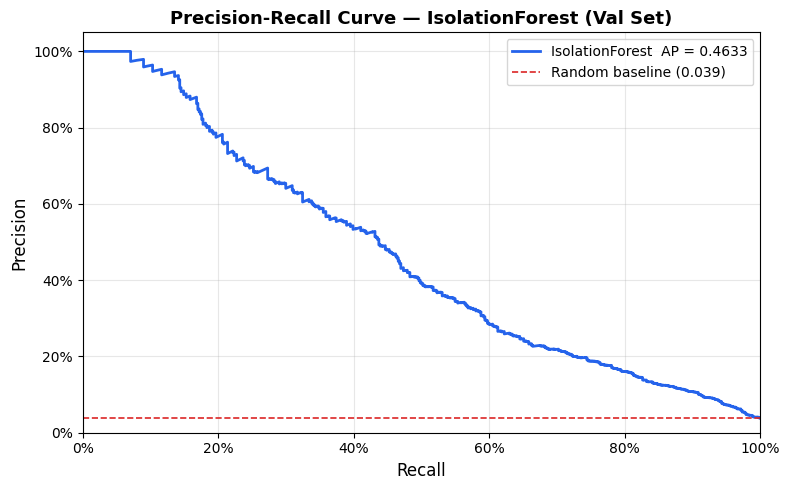

Saved /content/artifacts/pr_curve.png
Average Precision (val) : 0.4633
PR curve logged to MLflow.


In [14]:
# Cell 13: Precision-Recall Curve

y_true_val     = val_merged['is_anomalous'].values.astype(int)
scores_flipped = -val_merged['anomaly_score'].values   # flip: higher → more anomalous

prec_arr, rec_arr, _ = precision_recall_curve(y_true_val, scores_flipped)
ap_val = average_precision_score(y_true_val, scores_flipped)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_arr, prec_arr, lw=2, color='#2563EB',
        label=f'IsolationForest  AP = {ap_val:.4f}')
ax.axhline(y=y_true_val.mean(), color='#DC2626', lw=1.2, ls='--',
           label=f'Random baseline ({y_true_val.mean():.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — IsolationForest (Val Set)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1]);  ax.set_ylim([0, 1.05])
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(True, alpha=0.3)
fig.tight_layout()

pr_path = os.path.join(ARTIFACT_DIR, 'pr_curve.png')
fig.savefig(pr_path, dpi=150)
plt.show()

mlflow.log_metric('val_average_precision', ap_val)
mlflow.log_artifact(pr_path)
print(f'Saved {pr_path}')
print(f'Average Precision (val) : {ap_val:.4f}')
print('PR curve logged to MLflow.')

## Cell 14 — Permutation Importance

Estimates feature importance by measuring how much model performance drops
when each feature is randomly shuffled.

**Sign-flip fix:** `permutation_importance` calls the scorer repeatedly.
Using the string `'average_precision'` would invoke sklearn's default scorer,
which calls `decision_function` directly without negating it — producing backwards
results (shuffling an important feature would *improve* apparent AP because
degrading the normal-point scores accidentally raises anomaly scores).

Fix: provide a custom scorer that negates `decision_function` before computing
`average_precision_score`, matching the same convention used in Cell 13.

Baseline AP (flipped scorer, no permutation): 0.4633
Computing permutation importance (n_repeats=10) …

Top 15 features (Δ AP when shuffled):
   1. hotspot_session_ratio                Δ AP = +0.0882
   2. hotspot_sessions                     Δ AP = +0.0753
   3. hotspot_sum_7d                       Δ AP = +0.0677
   4. hotspot_sum_14d                      Δ AP = +0.0538
   5. billing_ratio                        Δ AP = +0.0365
   6. billing_gap_mb                       Δ AP = +0.0233
   7. trend_slope_14d                      Δ AP = +0.0196
   8. tier_support                         Δ AP = +0.0167
   9. offpeak_ratio                        Δ AP = +0.0142
  10. billed_mb                            Δ AP = +0.0130
  11. vol_rolling_14d_std                  Δ AP = +0.0099
  12. tier_professional                    Δ AP = +0.0067
  13. upload_ratio                         Δ AP = +0.0055
  14. vol_rolling_7d_std                   Δ AP = +0.0047
  15. offpeak_mb                           Δ A

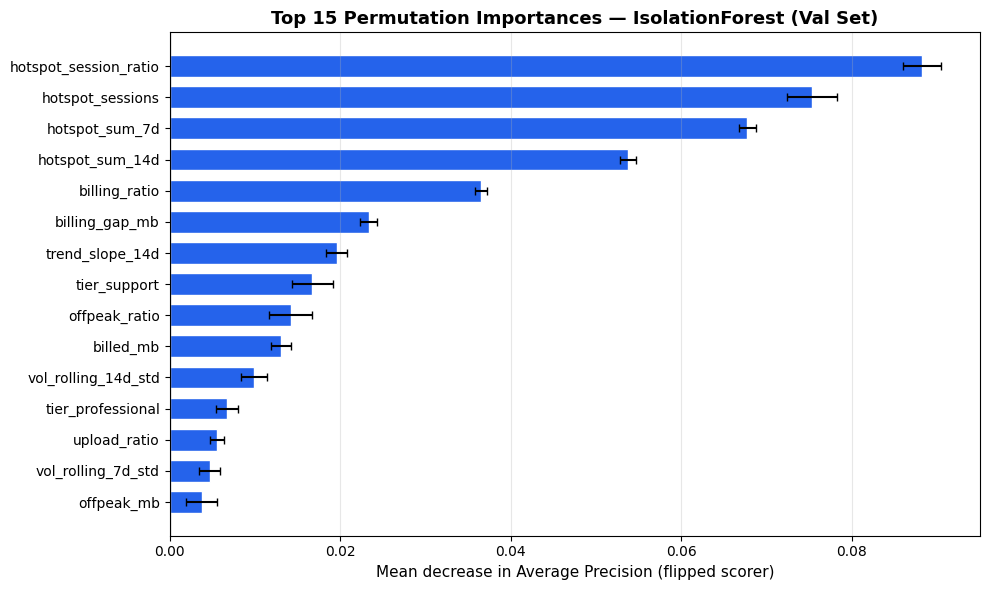


Saved /content/artifacts/permutation_importance.png
 Permutation importance logged to MLflow.


In [15]:
# Cell 14: Permutation Importance

# Custom scorer: negate decision_function so higher score = more anomalous
def _flipped_ap(estimator, X, y):
    return average_precision_score(y, -estimator.decision_function(X))

y_true_val = val_merged['is_anomalous'].values.astype(int)
baseline   = _flipped_ap(iso, X_val, y_true_val)
print(f'Baseline AP (flipped scorer, no permutation): {baseline:.4f}')
print('Computing permutation importance (n_repeats=10) …')

perm = permutation_importance(
    iso, X_val, y_true_val,
    n_repeats=10,
    random_state=SEED,
    scoring=_flipped_ap,
    n_jobs=-1,
)

TOP_N      = 15
sorted_idx = np.argsort(perm.importances_mean)[::-1][:TOP_N]
top_feats  = [feature_cols[i] for i in sorted_idx]
top_imps   = perm.importances_mean[sorted_idx]
top_stds   = perm.importances_std[sorted_idx]

print(f'\nTop {TOP_N} features (Δ AP when shuffled):')
for rank, (f, imp) in enumerate(zip(top_feats, top_imps), 1):
    print(f'  {rank:>2}. {f:<35}  Δ AP = {imp:+.4f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#2563EB' if v >= 0 else '#DC2626' for v in top_imps]
ax.barh(range(TOP_N), top_imps[::-1], xerr=top_stds[::-1],
        color=colors[::-1], edgecolor='white', height=0.7, capsize=3)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_feats[::-1], fontsize=10)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean decrease in Average Precision (flipped scorer)', fontsize=11)
ax.set_title(f'Top {TOP_N} Permutation Importances — IsolationForest (Val Set)',
             fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()

perm_path = os.path.join(ARTIFACT_DIR, 'permutation_importance.png')
fig.savefig(perm_path, dpi=150)
plt.show()

mlflow.log_artifact(perm_path)
print(f'\nSaved {perm_path}')
print(' Permutation importance logged to MLflow.')

## Cell 15 — Save Model, Print Summary, End Run

Logs the fitted model to MLflow using `mlflow.sklearn.log_model`, saves a
portable `isolation_forest.joblib` file independent of MLflow storage,
prints the run summary, and closes the MLflow run with `mlflow.end_run()`.

**MLflow 3.x note:** `skops_trusted_types` must include `sklearn.tree._tree.Tree`
when logging any scikit-learn tree-ensemble model, otherwise MLflow's skops
security layer raises `UntrustedTypesFoundException`.

In [16]:
# Cell 15: Save Model, Summary, End Run

# 1. Log model to MLflow
print('Logging model to MLflow …')
mlflow.sklearn.log_model(
    iso, 'model',
    # MLflow 3.x requires explicit trust for tree-based estimator internals
    skops_trusted_types=['sklearn.tree._tree.Tree'],
)
print(' Model logged to MLflow artifact store.')

# 2. Save plain joblib (portable, independent of MLflow's artifact store)
joblib_path = os.path.join(ARTIFACT_DIR, 'isolation_forest.joblib')
joblib.dump(iso, joblib_path)
print(f' Model saved: {joblib_path}')

# 3. Run summary
print(f"\n{'='*68}")
print(f'  RUN COMPLETE')
print(f'  Run ID        : {RUN_ID}')
print(f'  MLflow DB     : {MLFLOW_DB}')
print(f'  Artifacts dir : {os.path.abspath(ARTIFACT_DIR)}')
print()
print(f"  VAL   F1={val_metrics['f1_overall']:.4f}  "
      f"Prec={val_metrics['precision_overall']:.4f}  "
      f"Rec={val_metrics['recall_overall']:.4f}  "
      f"AP={ap_val:.4f}")
print(f"  TEST  F1={test_metrics['f1_overall']:.4f}  "
      f"Prec={test_metrics['precision_overall']:.4f}  "
      f"Rec={test_metrics['recall_overall']:.4f}")
print(f"{'='*68}")

# 4. Close the MLflow run
mlflow.end_run()
print('\n MLflow run closed.')

2026/10/01 00:15:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logging model to MLflow …
 Model logged to MLflow artifact store.
 Model saved: /content/artifacts/isolation_forest.joblib

  RUN COMPLETE
  Run ID        : 1defa620066745398a061238d1a99075
  MLflow DB     : sqlite:///mlruns.db
  Artifacts dir : /content/artifacts

  VAL   F1=0.4215  Prec=0.3404  Rec=0.5534  AP=0.4633
  TEST  F1=0.4134  Prec=0.2932  Rec=0.7008

 MLflow run closed.
